# External Background Sensitivity tests

## Purpose

Having determined and validated robust background and ICGC corrections in the previous notebook [06_ext_contaminant_ICGC_corrections](Coma_CSS_color/06_ext_contaminant_ICGC_corrections.ipynb) we now need to ask the question...

>How do the inner, annulus, and inner–environment diagnostics change when independently calibrated fg/bg and ICGC components are applied?

## Motivation

What we are aiming for here is not to maximize significance, but to test the sensitivity to the external corrections.

## Outline

We'll do this in layers:

1. No external correction — your current clean baseline.
2. Subtract fg/bg only.
3. Subtract fg/bg + constant ICGC baseline.
4. Compare the resulting:

$$ \langle P_{\rm blue}\rangle_{\rm inner}, \quad \langle P_{\rm blue}\rangle_{\rm annulus}, \quad \Delta P_{\rm IE}. $$

5. Re-run the environmental correlations for each version.
6. Then do a modest sensitivity grid on:
   - ICGC normalization,
   - ICGC Pblue,
   - fg/bg Pblue.

The key aim is to see whether the physical picture survives reasonable external corrections.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Tuple, Optional, Dict
from tqdm.auto import tqdm

import ast
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.stats import rayleightest
from scipy.stats import binomtest, ks_2samp, chi2, spearmanr,  pearsonr, linregress
from shapely.geometry import Polygon, Point
import logging

from src.config import (
    Columns,
    BCG,
    AnalysisConfig,
    ClusterCenter,
)

RNG_SEED = 20260830
rng = np.random.default_rng(RNG_SEED)

N_PERM = 1000   # development run

%load_ext autoreload
%autoreload 2

In [4]:
# logging function

def setup_logging(verbose=False, name = "Coma_GCs_debug"):
    """
    Call this once at the top of the notebook.
    If verbose=True, DEBUG messages will show; otherwise only INFO+.
    """    
    # Remove any root handlers (if I had root-level logging before)
    for h in logging.root.handlers[:]:
        logging.root.removeHandler(h)

    # Get named logger and clear *its* handlers + disable propagation
    logger = logging.getLogger(name)
    for h in logger.handlers[:]:
        logger.removeHandler(h)
    logger.propagate = False

    # Set logger’s level
    logger.setLevel(logging.DEBUG)   # we capture everything here

    # INFO-only handler (no timestamp)
    info_handler = logging.StreamHandler()
    info_handler.setLevel(logging.INFO)
    info_handler.addFilter(lambda rec: rec.levelno == logging.INFO)
    info_handler.setFormatter(logging.Formatter("%(message)s"))
    logger.addHandler(info_handler)

    # non-INFO handler (timestamped, DEBUG or WARNING+)
    other = logging.StreamHandler()
    other.setLevel(logging.DEBUG if verbose else logging.WARNING)
    other.addFilter(lambda rec: rec.levelno != logging.INFO)
    # allow only your logger’s DEBUG (if you still want a name-filter):
    other.addFilter(lambda rec: rec.levelno != logging.DEBUG or rec.name == name)
    fmt = "[%(levelname)s] %(asctime)s.%(msecs)03d %(message)s"
    other.setFormatter(logging.Formatter(fmt, datefmt="%H:%M:%S"))
    logger.addHandler(other)


In [5]:
# Set verbosity here:
name = "ext_contaminant_and_icgc_sensitivity"
setup_logging(verbose=True, name = name)   # or False

# testing logging
logger = logging.getLogger(name)
logger.debug("Debug messages are ON")
logger.info("Info messages are always shown")
logger.warning("Warnings also show up")


[DEBUG] 10:59:34.753 Debug messages are ON
Info messages are always shown
[WARNING] 10:59:34.754 Warnings also show up


# Initialization

## Load in galaxies

Load in a `csv` file, which has been produced from manual and online archives, and saved in `Coma_Gal_List_Create.ipynb`, so this can be used in the calculation and plotting routines.

A second file of more data from the SIMBAD and NED archives has bee extracted, but this has indeterminate or somewhat inconsistent effective radii.

Select using `archive = True` or `False` if "manual" data is preferred.


In [6]:
def prep_gal_shapes(gals_df: pd.DataFrame) -> pd.DataFrame:
    g = gals_df.copy()

    # Convert minor axis from arcmin -> arcsec when present
    # (Your 'galdim_minaxis' is arcmin per your note)
    g["minor_axis_arcsec"] = np.where(
        np.isfinite(g["galdim_minaxis"]),
        g["galdim_minaxis"].astype(float) * 60.0,
        np.nan
    )

    # Axis ratio q=b/a using available axes (ratio is robust to diameter vs semi-axis ambiguity)
    a = g["major_axis_arcsec"].astype(float)
    b = g["minor_axis_arcsec"].astype(float)

    q = b / a
    # Clip to sane range; if missing, default to circular
    g["q_axis"] = np.where(np.isfinite(q), np.clip(q, 0.2, 1.0), 1.0)

    # Clean PA; if missing, set 0 (ellipse aligned N-S; effect minimal for q~1)
    g["pa_deg"] = pd.to_numeric(g["galdim_angle"], errors="coerce").fillna(0.0)

    return g


In [7]:
archive = True
if archive:
    logger.warning('NOTE: Loading SIMBAD / NED extracted data for Coma cluster galaxies - NOTE. With colors')
    # Load in the file of galaxy data extracted from archives OR 
    gals_df = pd.read_csv('../Coma_LSD_CSS/data/gals_data_from_archives.csv')
    gals_df_from_csv = gals_df.copy()
    gals_df = prep_gal_shapes(gals_df)
else:
    logger.warning('NOTE: Loading manual data for Coma cluster galaxies')
    # Load in the file of sanitised and augmented galaxy data  
    gals_df = pd.read_csv('../Coma_LSD_CSS/data/gals_data_cleaned.csv')
gals_df.tail(5)

[WARNING] 10:59:37.161 NOTE: Loading SIMBAD / NED extracted data for Coma cluster galaxies - NOTE. With colors


,name,ra,dec,otype,z,Vmag_simbad_raw,Bmag_simbad_raw,BV_simbad_raw,gmag_simbad_raw,rmag_simbad_raw,...,Re_GCS_scale,Re_GCS_arcsec,n_gcs_prior,n_gcs_red_prior,n_gcs_blue_prior,gal_color,gal_color_src,minor_axis_arcsec,q_axis,pa_deg
169,NGC 4874,194.898789,27.959248,LIN,0.023910,12.71,13.7,0.990000,12.6472,11.7979,...,4.8,142.014382,NaN,NaN,NaN,1.254257,g-i,135.64440,0.966099,63.0
170,NGC 4869,194.847328,27.911592,EmG,0.022879,13.52,14.9,1.379999,14.4290,13.6240,...,3.2,23.865957,NaN,NaN,NaN,1.230054,g-i,41.45118,0.834300,47.0
171,NGC 4889,195.033738,27.977025,EmG,0.021500,11.30,13.0,1.700000,12.3528,11.5017,...,4.8,110.525917,NaN,NaN,NaN,1.033334,g-i,109.01400,0.621500,75.0
172,SDSS J130042.56+280658.6,195.177360,28.116320,LSB,0.020701,18.24,NaN,NaN,17.6480,17.0110,...,3.2,33.052243,NaN,NaN,NaN,0.868321,g-i,19.49800,1.000000,0.0
173,Coma cluster,195.017071,27.977025,CLUSTER,0.021500,NaN,NaN,NaN,NaN,NaN,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.0


In [8]:
# Test the load
gal1=['IC 4051','NGC 4883','NGC 4876']
for gal_i in gal1:
    gal_row = gals_df.loc[gals_df['name'] == gal_i].iloc[0]
    print(f"{gal_i}: mv={gal_row['mV_app']:4.2f} mag, MV={gal_row['MV_abs']:5.2f} mag")


IC 4051: mv=13.34 mag, MV=-21.66 mag
NGC 4883: mv=14.34 mag, MV=-20.66 mag
NGC 4876: mv=14.49 mag, MV=-20.51 mag


In [9]:
gals_df.columns

Index(['name', 'ra', 'dec', 'otype', 'z', 'Vmag_simbad_raw', 'Bmag_simbad_raw',
       'BV_simbad_raw', 'gmag_simbad_raw', 'rmag_simbad_raw',
       'imag_simbad_raw', 'zmag_simbad_raw', 'gr_simbad_raw', 'gi_simbad_raw',
       'major_axis_arcsec', 'galdim_minaxis', 'galdim_angle', 'dim_source',
       'galdim_qual', 'galdim_bibcode', 'dim_ref', 'MV_simbad_raw',
       'show_label', 'Re_arcsec', 'otype_family', 'morph_type', 'major_kpc',
       'is_large_E', 'sdss_objid', 'Re_r_arcsec', 'Re_r_arcsec_circ',
       'g_cmodel_sdss', 'r_cmodel_sdss', 'i_cmodel_sdss', 'gerr_cmodel_sdss',
       'rerr_cmodel_sdss', 'ierr_cmodel_sdss', 'Ag_sdss', 'Ar_sdss', 'Ai_sdss',
       'g0_cmodel_sdss', 'r0_cmodel_sdss', 'i0_cmodel_sdss', 'sdss_phot_ok',
       'gr0_sdss', 'gi0_sdss', 'g_model_sdss', 'r_model_sdss', 'i_model_sdss',
       'gerr_model_sdss', 'rerr_model_sdss', 'ierr_model_sdss',
       'g0_model_sdss', 'r0_model_sdss', 'i0_model_sdss', 'Vmag_sdss',
       'Vmag_sdss_err', 'V_source', 'mV

## Load CSS candidates

Now we have galaxy data, we need to load up the CSS candidate file. 

In [10]:
#inFileName = "allpointings_master.dat_NoOverlap"
# inFileName = "data/newallpointingsmaster_26may2021.dat"  # with delimeter ' '
inFileName = "data/inspectedpointings_merged_19Oct2024.csv"  # with delimieter ','

inFile = open(inFileName, 'r')
lines = inFile.readlines()
inFile.close

data = pd.read_csv(inFileName, delimiter=',')


and then we need to filter for color on CSS in general, and additional filter for UCDs on the tighter color range and luminosity, and outlined in paper 1. Color value are 

- CSS: *color* 0.5 < (F475W − F814W ) < 2.5 and 
- UCD: *color* 1.3 < (F475W − F814W ) < 2.1 and *magnitude* F814W < 22.9 mag


In [11]:
data = data[(data['color'] > 0.5) & (data['color'] < 2.5)]
data_bright = data.loc[data['mag_814']<=25.0].copy()  # take a cut of data where completeness is > ~90% 

# Define the range for UCD 'color' and 'mag_814'
ucd_color_min, ucd_color_max = 1.3, 2.1     #
ucd_mag_814_min, ucd_mag_814_max = 0, 22.9  # should be 0 mag to 22.9 mag

# remove duplicated data
data = data.drop_duplicates()

# Filter the DataFrame
gcs_df = data[(data['color'] <= ucd_color_min) | (data['color'] >= ucd_color_max) |
                 (data['mag_814'] <= ucd_mag_814_min) | (data['mag_814'] >= ucd_mag_814_max)]
ucd_df = data[(data['color'] > ucd_color_min) & (data['color'] < ucd_color_max) &
                 (data['mag_814'] > ucd_mag_814_min) & (data['mag_814'] < ucd_mag_814_max)]


In [12]:
total_gcs = len(gcs_df)
total_ucds = len(ucd_df)
total_css = len(data)
total_bright = len(data_bright)

print('Total GCs: ', total_gcs)
print('Total UCDs: ', total_ucds)
print('Total count: ', total_css)
print('Total bright (F814W ≤ 25.0 mag): ', total_bright)
print('Mag F814W min, max:', np.min(data['mag_814']), np.max(data['mag_814']) )
print('Mag F475W min, max:', np.min(data['mag_475']), np.max(data['mag_475']) )

data.head(5)

Total GCs:  22104
Total UCDs:  523
Total count:  22627
Total bright (F814W ≤ 25.0 mag):  10304
Mag F814W min, max: 16.66917944 29.0727298
Mag F475W min, max: 18.59635274 31.0122151


,x_wcs,y_wcs,flux_814,flux_475,mag_814,mag_475,color,pointing,x,y,type,x_wcs_f,y_wcs_f,gc_type_f,pointing_f,Unnamed: 15
0,194.09794,27.244074,0.458373,0.203884,26.152547,27.681062,1.528516,OS21,708.977,3994.384,gc,194.09794,27.244074,gc,OS21,NaN
1,194.09828,27.212645,1.207550,1.165456,25.100832,25.788280,0.687449,OS21,2964.827,4170.375,gc,194.09828,27.212645,gc,OS21,NaN
3,194.09916,27.222516,4.788598,2.630347,23.605074,24.904488,1.299414,OS21,2261.617,4052.017,gc,194.09916,27.222516,gc,OS21,NaN
4,194.09917,27.213105,4.268017,1.134324,23.730029,25.817677,2.087648,OS21,2937.748,4109.924,gc,194.09917,27.213105,gc,OS21,NaN
5,194.09971,27.207500,2.269763,2.564432,24.415643,24.932042,0.516399,OS21,3342.696,4111.336,gc,194.09971,27.207500,gc,OS21,NaN


In [13]:
data.columns

Index(['x_wcs', 'y_wcs', 'flux_814', 'flux_475', 'mag_814', 'mag_475', 'color',
       'pointing', 'x', 'y', 'type', 'x_wcs_f', 'y_wcs_f', 'gc_type_f',
       'pointing_f', 'Unnamed: 15'],
      dtype='str')

## Load and verify the metrics quantities

In [14]:
metrics_df = pd.read_csv(
    "../Coma_CSS_color/data/metrics_df_fiducial_orig_recal.csv"
)

PB_METRIC = "Delta_Pblue_mean_bgsub"
COLOR_METRIC = "Delta_mean_color_bgsub"

required = [
    "mean_color",
    "mean_color_bgsub",
    COLOR_METRIC,
    PB_METRIC,
]

for col in required:
    print(f"{col:30s}", col in metrics_df.columns)



mean_color                     True
mean_color_bgsub               True
Delta_mean_color_bgsub         True
Delta_Pblue_mean_bgsub         True


## Check environmental metrics and baseline


In [15]:
sub = metrics_df[
    ["Delta_Pblue_mean_bgsub",
     "gc_bg_voronoi_density_arcsec2_inv"]
].dropna()

rho_obs, p_obs = spearmanr(
    sub["Delta_Pblue_mean_bgsub"],
    sub["gc_bg_voronoi_density_arcsec2_inv"]
)

print(rho_obs, p_obs)

-0.4420041180507892 9.183121292985238e-06


In [16]:
RHO_OBS = rho_obs
P_OBS   = p_obs

# Add $P_\mathrm{blue}$ to CSS data

In [17]:
# import numpy as np
# from typing import Tuple, Optional, Callable

# def _normal_pdf(x: np.ndarray, mu: np.ndarray, sigma: np.ndarray) -> np.ndarray:
#     """Vectorized Normal PDF."""
#     x = np.asarray(x, dtype=float)
#     mu = np.asarray(mu, dtype=float)
#     sigma = np.asarray(sigma, dtype=float)
#     return np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (np.sqrt(2.0 * np.pi) * sigma)

# # These were the submitted parameters for paper three, but I found an indexing error (see. Coma_Gal_Color_CMD.ipynb)
# #
#     # gmm_params: Tuple[Tuple[float, float, float, float, float], ...] = (
#     #     (1.58, 0.30, 1.76, 0.19, 0.54),  # 23-24
#     #     (1.51, 0.15, 1.68, 0.23, 0.59),  # 24-25
#     #     (1.46, 0.18, 1.67, 0.25, 0.55),  # 25-26
#     #     (1.40, 0.22, 1.64, 0.28, 0.57),  # 26-27
#     # ),

# def compute_Pblue(
#     mag814: np.ndarray,
#     color: np.ndarray,
#     *,
#     bright_mag_cut: float = 23.0,
#     # mag-binned mixture model for >= bright_mag_cut
#     mag_edges: Tuple[float, ...] = (23.0, 24.0, 25.0, 26.0, 27.0),
#     # These are the 'recalibrated values'
#     gmm_params: Tuple[Tuple[float, float, float, float, float], ...] = (
#         (1.521, 0.162, 1.707, 0.229, 0.56),  # 23-24
#         (1.457, 0.176, 1.668, 0.246, 0.58),  # 24-25
#         (1.399, 0.224, 1.641, 0.282, 0.57),  # 25-26
#         (1.217, 0.183, 1.596, 0.291, 0.45),  # 26-27
#     ),
#     # faint handling
#     faint_mode: str = "extend",   # "extend" or "clamp"
#     faint_max_edge: float = 28.0, # used only if extend
#     # optional prior modifier (later): fb(R) model
#     # If provided, pass an array fb of shape (N,) OR provide fb_func(r) separately.
#     fb: Optional[np.ndarray] = None,
# ) -> Tuple[np.ndarray, np.ndarray]:
#     """
#     Compute P(blue | color, mag) under a mag-binned 2-Gaussian mixture.

#     Returns:
#       Pblue (N,) float array
#       mag_bin_id (N,) int array (bright regime -> -1)
#     """
#     mag814 = np.asarray(mag814, dtype=float)
#     color = np.asarray(color, dtype=float)
#     if mag814.shape != color.shape:
#         raise ValueError("mag814 and color must have the same shape.")

#     N = mag814.size
#     Pblue = np.full(N, np.nan, dtype=float)
#     mag_bin_id = np.full(N, -1, dtype=int)

#     # Bright regime: undefined for bimodality by construction
#     bright = mag814 < bright_mag_cut
#     mid_or_faint = ~bright

#     # Prepare edges/params with faint handling
#     edges = np.asarray(mag_edges, dtype=float)
#     if faint_mode not in ("extend", "clamp"):
#         raise ValueError('faint_mode must be either "extend" or "clamp".')
#     params = np.array(gmm_params, dtype=float)
#     nbins = edges.size - 1
#     if params.shape[0] != nbins:
#         raise ValueError("gmm_params length must match len(mag_edges)-1.")

#     if faint_mode == "extend":
#         if faint_max_edge <= edges[-1]:
#             raise ValueError("faint_max_edge must be > mag_edges[-1] when extend.")
#         edges = np.concatenate([edges, [float(faint_max_edge)]])
#         params = np.vstack([params, params[-1:]])
#         nbins = edges.size - 1

#     if np.any(mid_or_faint):
#         m = mag814[mid_or_faint]
#         c = color[mid_or_faint]

#         bin_id = np.digitize(m, edges) - 1
#         bin_id = np.clip(bin_id, 0, nbins - 1)

#         mu_b = params[bin_id, 0]
#         sg_b = params[bin_id, 1]
#         mu_r = params[bin_id, 2]
#         sg_r = params[bin_id, 3]
#         w_b  = params[bin_id, 4]

#         # Likelihood terms
#         pb = w_b * _normal_pdf(c, mu_b, sg_b)
#         pr = (1.0 - w_b) * _normal_pdf(c, mu_r, sg_r)

#         # Optional prior modifier (later): replace w_b -> fb*w_b and (1-w_b)->(1-fb)*(1-w_b)?
#         # For now, if fb is provided, treat it as a multiplicative reweighting of the mixture prior:
#         if fb is not None:
#             fb_arr = np.asarray(fb, dtype=float)
#             if fb_arr.shape != mag814.shape:
#                 raise ValueError("fb must have the same shape as mag814/color if provided.")
#             fb_sub = fb_arr[mid_or_faint]
#             pb = fb_sub * pb
#             pr = (1.0 - fb_sub) * pr

#         denom = pb + pr
#         # Safe division
#         p = np.divide(pb, denom, out=np.full_like(pb, np.nan), where=denom > 0)

#         Pblue[mid_or_faint] = p
#         mag_bin_id[mid_or_faint] = bin_id

#     return Pblue, mag_bin_id


In [18]:
# Add in blue probability (based on magnitude and color of GCs)
# NOTE: The compute_Pblue function was originally below, but moved above as needs executing before 
# running this cell.

from src.color_metrics import compute_Pblue

Pblue_all, mag_bin_id = compute_Pblue(
    mag814=data["mag_814"].values,
    color=data["color"].values
)

data = data.copy()
data["Pblue"] = Pblue_all


## Check columns

In [19]:
keywords = [
    "Pblue",
    "_eff"
]

for keyword in keywords:
    matches = [
        c for c in metrics_df
        if keyword.lower() in c.lower()
    ]

    print(f"\n{keyword}:")
    print(matches)




Pblue:
['N_inner_Pblue', 'N_annulus_Pblue', 'matched_color_Pblue_samples', 'Pblue_mean_inner_raw', 'Pblue_mean_annulus', 'N_eff_bgsub_Pblue', 'N_geom_bgsub_Pblue', 'sum_Pblue_inner', 'sum_Pblue_annulus', 'Pblue_std_inner', 'Pblue_std_annulus', 'Pblue_inner_meets_min', 'Pblue_annulus_nonzero', 'min_gc_for_Pblue', 'Pblue_mean', 'Pblue_mean_err', 'Pblue_mean_bgsub', 'Pblue_mean_bgsub_geom', 'Pblue_mean_exp', 'Delta_Pblue_mean', 'Pblue_mean_bgsub_exp', 'Delta_Pblue_mean_bgsub', 'Pblue_mean_bgsub_geom_exp', 'Delta_Pblue_mean_bgsub_geom']

_eff:
['A_ap_eff', 'A_bg_eff', 'A_ap_eff_over_geom', 'A_bg_eff_over_geom', 'alpha_eff', 'N_eff_bgsub_color', 'N_eff_bgsub_Pblue']


# Build cut-down routines

In [20]:
perm_data = data.copy().reset_index(drop=True)
perm_data["_perm_idx"] = np.arange(len(perm_data), dtype=int)

pblue_orig = perm_data["Pblue"].to_numpy(dtype=float)

In [21]:

def select_gc_samples_for_galaxy(
    data,
    gal_row,
    cols,
    kRe_inner=8.0,
    kRe_outer=(12.0, 20.0),
):
    """
    Returns inner and annulus GC samples for one galaxy.
    """
    kRe = elliptical_radius_kRe(
        data[cols.gc_ra].values,
        data[cols.gc_dec].values,
        gal_row[cols.gal_ra],
        gal_row[cols.gal_dec],
        gal_row[cols.gal_Re_arcsec],
        gal_row["q_axis"],
        gal_row["pa_deg"],
    )

    data = data.copy()
    data["kRe"] = kRe

    inner = data[kRe <= kRe_inner]
    ann = data[(kRe > kRe_outer[0]) & (kRe <= kRe_outer[1])]

    return inner, ann

def elliptical_radius_kRe(
    gc_ra, gc_dec,
    gal_ra, gal_dec,
    Re_arcsec,
    q_axis,
    pa_deg,
):
    """
    Compute elliptical radius in units of Re for each GC relative to a galaxy.
    PA assumed East of North (SIMBAD convention).
    """
    # SkyCoord objects
    gc = SkyCoord(gc_ra * u.deg, gc_dec * u.deg)
    gal = SkyCoord(gal_ra * u.deg, gal_dec * u.deg)

    # Tangent-plane offsets (arcsec)
    dra = (gc.ra - gal.ra).to(u.arcsec).value * np.cos(gal.dec.to(u.rad).value)
    ddec = (gc.dec - gal.dec).to(u.arcsec).value

    # Rotate into galaxy frame
    pa = np.deg2rad(pa_deg)
    x =  dra * np.cos(pa) + ddec * np.sin(pa)
    y = -dra * np.sin(pa) + ddec * np.cos(pa)

    # Elliptical radius (arcsec)
    r_ell = np.sqrt(x**2 + (y / q_axis)**2)

    # Return in units of Re
    return r_ell / Re_arcsec

## Build the membership cache once

In [22]:
@dataclass
class Columns:
    # galaxy table columns
    gal_id: str = "name"
    gal_ra: str = "ra"
    gal_dec: str = "dec"
    gal_Re_arcsec: str = "Re_best_arcsec"
    gal_MV: str = "MV_abs"

    # GC table columns
    gc_ra: str = "x_wcs"
    gc_dec: str = "y_wcs"
    gc_color: str = "color"           # e.g., F475W-F814W
    gc_mag: Optional[str] = "mag_814"  # optional
    gc_host: Optional[str] = "gal_id"  # if we already have assignment

@dataclass
class AnalysisConfig:
    aperture_Re: float = 8.0
    # optional background annulus for "local GC density"
    bg_annulus_inner_Re: float = 12.0
    bg_annulus_outer_Re: float = 20.0

    # bootstrap
    n_boot: int = 300
    min_gc_for_gmm: int = 30  # below this, we can fall back to median-only
    min_gc_for_Pblue: int = 10
    # baseline fit
    huber_eps: float = 1.35   # robust regression tuning


In [23]:
galaxy_cache = {}

cols = Columns
cfg = AnalysisConfig

for _, gal in tqdm(
    gals_df.iterrows(),
    total=len(gals_df),
    desc="Caching aperture membership"
):
    inner, ann = select_gc_samples_for_galaxy(
        perm_data,
        gal,
        cols,
        kRe_inner=cfg.aperture_Re,
        kRe_outer=(
            cfg.bg_annulus_inner_Re,
            cfg.bg_annulus_outer_Re,
        ),
    )

    # Use EXACTLY the same eligibility mask as the current
    # Pblue calculation in compute_metrics_for_galaxy.
    inner_mask = np.isfinite(inner["color"].to_numpy(dtype=float)) & np.isfinite(inner["Pblue"].to_numpy(dtype=float))
    ann_mask = np.isfinite(ann["color"].to_numpy(dtype=float)) & np.isfinite(ann["Pblue"].to_numpy(dtype=float))

    inner_idx = inner.loc[inner_mask, "_perm_idx"].to_numpy(dtype=int)
    ann_idx   = ann.loc[ann_mask, "_perm_idx"].to_numpy(dtype=int)

    gal_id = gal[cols.gal_id]

    galaxy_cache[gal_id] = {
        "inner_idx": inner_idx,
        "ann_idx": ann_idx,
    }  


Caching aperture membership:   0%|          | 0/174 [00:00<?, ?it/s]

## Pull fixed baseline metrics

In [24]:
metrics_df["Delta_P_IE"] = (
    metrics_df["Pblue_mean_inner_raw"]
    - metrics_df["Pblue_mean_annulus"]
)

fixed_metrics = (
    metrics_df
    .set_index(cols.gal_id)
)


/var/folders/_d/2vszj0nd6532d6knr4c9lnrw0000gn/T/ipykernel_92298/4244759424.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  metrics_df["Delta_P_IE"] = (


In [25]:
science_ids = fixed_metrics.index[
    np.isfinite(fixed_metrics["Delta_Pblue_mean_bgsub"])
]
len(science_ids)

93

In [26]:
fixed_metrics["r_bg"] = (
    fixed_metrics["alpha_eff"]
    * fixed_metrics["N_annulus_Pblue"]
    / fixed_metrics["N_inner_Pblue"]
)


/var/folders/_d/2vszj0nd6532d6knr4c9lnrw0000gn/T/ipykernel_92298/3521669378.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fixed_metrics["r_bg"] = (


# Calculate three versions of observable

First section now, we need to compare

- Baseline
- fg/bg correction
- fg/bg + ICGC correction

For each galaxy, we need to use the same inner and annulus samples from the membership cache, and calculate the expected external counts from the effective areas.

In [27]:
PENG_BG_DENSITY = 2.8          # arcmin^-2
PBLUE_BG = 0.535

PENG_ICGC_DENSITY = 18.1       # arcmin^-2, observed-catalog equivalent
PBLUE_ICGC = 0.660


In [28]:
def expected_external_counts(area_arcsec2, sigma_arcmin2):
    return (area_arcsec2 / 3600.0) * sigma_arcmin2
    

For each aperture define the expected surface density (in n/arcmin^2)

In [29]:
n_bg_inner = expected_external_counts(
    metrics_df["A_ap_eff"],
    PENG_BG_DENSITY,
)

n_bg_ann = expected_external_counts(
    metrics_df["A_bg_eff"],
    PENG_BG_DENSITY,
)

n_icgc_inner = expected_external_counts(
    metrics_df["A_ap_eff"],
    PENG_ICGC_DENSITY,
)

n_icgc_ann = expected_external_counts(
    metrics_df["A_bg_eff"],
    PENG_ICGC_DENSITY,
)

Define a transparent helper for subtracting a component from a mean-Pblue population

In [30]:
def correct_population_mean(
    n_obs,
    pblue_sum_obs,
    n_ext,
    pblue_ext,
):
    n_corr = n_obs - n_ext

    pblue_sum_corr = (
        pblue_sum_obs
        - n_ext * pblue_ext
    )

    out = np.full_like(
        np.asarray(n_corr, dtype=float),
        np.nan,
    )

    ok = n_corr > 0

    out[ok] = (
        np.asarray(pblue_sum_corr, dtype=float)[ok]
        / np.asarray(n_corr, dtype=float)[ok]
    )

    return out


Then we can calculate both the corrected inner and annulus parameters and then our P_IE inner environment diagnostic.

In [31]:
metrics_df["Pblue_inner_fgsub"] = correct_population_mean(
    metrics_df["N_inner_Pblue"],
    metrics_df["sum_Pblue_inner"],
    n_bg_inner,
    PBLUE_BG,
)

metrics_df["Pblue_ann_fgsub"] = correct_population_mean(
    metrics_df["N_annulus_Pblue"],
    metrics_df["sum_Pblue_annulus"],
    n_bg_ann,
    PBLUE_BG,
)

metrics_df["Delta_P_IE_fgsub"] = (
    metrics_df["Pblue_inner_fgsub"]
    - metrics_df["Pblue_ann_fgsub"]
)


/var/folders/_d/2vszj0nd6532d6knr4c9lnrw0000gn/T/ipykernel_92298/1956890834.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  metrics_df["Pblue_inner_fgsub"] = correct_population_mean(
/var/folders/_d/2vszj0nd6532d6knr4c9lnrw0000gn/T/ipykernel_92298/1956890834.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  metrics_df["Pblue_ann_fgsub"] = correct_population_mean(
/var/folders/_d/2vszj0nd6532d6knr4c9lnrw0000gn/T/ipykernel_92298/1956890834.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result

and similarly for the full external correction, for the inner...

In [32]:
n_ext_inner = n_bg_inner + n_icgc_inner

pblue_sum_ext_inner = (
    n_bg_inner * PBLUE_BG
    + n_icgc_inner * PBLUE_ICGC
)

n_corr_inner = (
    metrics_df["N_inner_Pblue"]
    - n_ext_inner
)

pblue_sum_corr_inner = (
    metrics_df["sum_Pblue_inner"]
    - pblue_sum_ext_inner
)

metrics_df["Pblue_inner_fg_icgc_sub"] = (
    pblue_sum_corr_inner / n_corr_inner
)


/var/folders/_d/2vszj0nd6532d6knr4c9lnrw0000gn/T/ipykernel_92298/967233638.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  metrics_df["Pblue_inner_fg_icgc_sub"] = (


and then the same for the annulus

In [33]:
n_ext_ann = n_bg_ann + n_icgc_ann

pblue_sum_ext_ann = (
    n_bg_ann * PBLUE_BG
    + n_icgc_ann * PBLUE_ICGC
)

n_corr_ann = (
    metrics_df["N_annulus_Pblue"]
    - n_ext_ann
)

pblue_sum_corr_ann = (
    metrics_df["sum_Pblue_annulus"]
    - pblue_sum_ext_ann
)

metrics_df["Pblue_ann_fg_icgc_sub"] = (
    pblue_sum_corr_ann / n_corr_ann
)


/var/folders/_d/2vszj0nd6532d6knr4c9lnrw0000gn/T/ipykernel_92298/7715941.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  metrics_df["Pblue_ann_fg_icgc_sub"] = (


## Test correction invasiveness

Make a sanity table before any correction analysis to see what the initial effect is.

In [37]:
check_cols = [
    "N_inner_Pblue",
    "N_annulus_Pblue",
    "Pblue_mean_inner_raw",
    "Pblue_mean_annulus",
    "Pblue_inner_fgsub",
    "Pblue_ann_fgsub",
    "Pblue_inner_fg_icgc_sub",
    "Pblue_ann_fg_icgc_sub",
]

print(
    metrics_df[check_cols]
    .describe()
    .to_string(float_format=lambda x: f"{x:.4f}")
)


       N_inner_Pblue  N_annulus_Pblue  Pblue_mean_inner_raw  Pblue_mean_annulus  Pblue_inner_fgsub  Pblue_ann_fgsub  Pblue_inner_fg_icgc_sub  Pblue_ann_fg_icgc_sub
count       174.0000         174.0000              130.0000            139.0000           130.0000         139.0000                 130.0000               139.0000
mean        172.8966         225.3621                0.5723              0.5879             0.5785           0.5993                   0.5209                 0.4937
std         777.3402         639.2404                0.0885              0.0695             0.1014           0.0904                   0.3087                 0.5942
min           0.0000           0.0000                0.3034              0.3368             0.3016           0.3219                  -2.1714                -4.3409
25%           0.2500           4.0000                0.5137              0.5500             0.5131           0.5506                   0.4527                 0.4863
50%          11.

There are some curious results here. The fg/bg-only correction looks well behaved. Means and dispersions change modestly:

$$ \langle P_{\rm blue}\rangle_{\rm inner}: 0.5723 \rightarrow 0.5785 $$ $$ \langle P_{\rm blue}\rangle_{\rm ann}: 0.5879 \rightarrow 0.5993. $$

So subtracting the independently measured non-Coma contaminant floor is not doing anything pathological.

The fg/bg + uniform ICGC correction absolutely is. We’re getting impossible values like:

$$ P_{\rm blue}<-2 $$

and

$$ P_{\rm blue}>2. $$

That can only happen because, for some galaxies, the assumed external ICGC contribution is comparable to or larger than the observed population in that aperture. In other words, the denominator

$$ N_{\rm corr} = N_{\rm obs} - N_{\rm fg/bg} - N_{\rm ICGC} $$

is getting very small or negative.

That is not just a coding nuisance — it is scientifically important. It implies a single uniform Peng ICGC floor cannot simply be subtracted galaxy-by-galaxy from these apertures and interpreted as a host-only population.

The next diagnostic we should therefore inspect will be the corrected counts themselves:

In [38]:
metrics_df["N_inner_fgsub"] = (
    metrics_df["N_inner_Pblue"]
    - n_bg_inner
)

metrics_df["N_ann_fgsub"] = (
    metrics_df["N_annulus_Pblue"]
    - n_bg_ann
)

metrics_df["N_inner_fg_icgc_sub"] = (
    metrics_df["N_inner_Pblue"]
    - n_bg_inner
    - n_icgc_inner
)

metrics_df["N_ann_fg_icgc_sub"] = (
    metrics_df["N_annulus_Pblue"]
    - n_bg_ann
    - n_icgc_ann
)


/var/folders/_d/2vszj0nd6532d6knr4c9lnrw0000gn/T/ipykernel_92298/2188486576.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  metrics_df["N_inner_fgsub"] = (
/var/folders/_d/2vszj0nd6532d6knr4c9lnrw0000gn/T/ipykernel_92298/2188486576.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  metrics_df["N_ann_fgsub"] = (
/var/folders/_d/2vszj0nd6532d6knr4c9lnrw0000gn/T/ipykernel_92298/2188486576.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor 

In [39]:
cols_check = [
    "N_inner_fgsub",
    "N_ann_fgsub",
    "N_inner_fg_icgc_sub",
    "N_ann_fg_icgc_sub",
]

print(
    metrics_df[cols_check]
    .describe()
    .to_string(float_format=lambda x: f"{x:.4f}")
)


       N_inner_fgsub  N_ann_fgsub  N_inner_fg_icgc_sub  N_ann_fg_icgc_sub
count       169.0000     169.0000             169.0000           169.0000
mean        174.7461     222.8407             153.6355           163.4409
std         775.9994     628.3942             697.1637           513.3262
min          -0.2574      -0.0747              -8.3291           -46.4562
25%           0.8744       3.8872               0.0000             0.0000
50%          11.7747      29.8767               4.6323             7.0501
75%          45.2974     131.0945              31.3366            70.5650
max        7324.9106    5848.2616            6471.0473          4576.4882


In [41]:
for col in cols_check:
    print(
        f"{col}: "
        f"N<=0 = {(metrics_df[col] <= 0).sum()}, "
        f"N<5 = {(metrics_df[col] < 5).sum()}"
    )


N_inner_fgsub: N<=0 = 39, N<5 = 63
N_ann_fgsub: N<=0 = 30, N<5 = 46
N_inner_fg_icgc_sub: N<=0 = 53, N<5 = 86
N_ann_fg_icgc_sub: N<=0 = 64, N<5 = 80


So, the real issue is not specifically the ICGC term. It is trying to turn an expected statistical background subtraction into a galaxy-by-galaxy population ratio for very sparse systems.

Let's restrict this to the 93-galaxy science sample.

In [44]:
print(metrics_df.index[:10])
print(metrics_df.index.name)

RangeIndex(start=0, stop=10, step=1)
None


In [46]:
missing = science_ids.difference(
    metrics_df["name"]
)

print("Missing:", len(missing))
print(missing.tolist())


Missing: 0
[]


Apply a stability diagnostic, rather than clipping the corrected Pblue to $[0,1]$, which would hide the failure mode. Instead we can explicitly flag cases where the residual population is too small to support a corrected mixture estimate.

In [47]:
MIN_CORR_COUNT = 10

metrics_df["inner_fgsub_valid"] = (
    metrics_df["N_inner_fgsub"] >= MIN_CORR_COUNT
)

metrics_df["ann_fgsub_valid"] = (
    metrics_df["N_ann_fgsub"] >= MIN_CORR_COUNT
)

metrics_df["inner_fg_icgc_valid"] = (
    metrics_df["N_inner_fg_icgc_sub"] >= MIN_CORR_COUNT
)

metrics_df["ann_fg_icgc_valid"] = (
    metrics_df["N_ann_fg_icgc_sub"] >= MIN_CORR_COUNT
)


/var/folders/_d/2vszj0nd6532d6knr4c9lnrw0000gn/T/ipykernel_92298/2065116065.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  metrics_df["inner_fgsub_valid"] = (
/var/folders/_d/2vszj0nd6532d6knr4c9lnrw0000gn/T/ipykernel_92298/2065116065.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  metrics_df["ann_fgsub_valid"] = (
/var/folders/_d/2vszj0nd6532d6knr4c9lnrw0000gn/T/ipykernel_92298/2065116065.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which h

In [57]:
metrics_df["N_bg_ext_inner"] = n_bg_inner
metrics_df["N_bg_ext_annulus"]   = n_bg_ann

metrics_df["N_icgc_inner"] = n_icgc_inner
metrics_df["N_icgc_annulus"]   = n_icgc_ann

/var/folders/_d/2vszj0nd6532d6knr4c9lnrw0000gn/T/ipykernel_92298/2615556972.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  metrics_df["N_bg_ext_annulus"]   = n_bg_ann
/var/folders/_d/2vszj0nd6532d6knr4c9lnrw0000gn/T/ipykernel_92298/2615556972.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  metrics_df["N_icgc_annulus"]   = n_icgc_ann


Create a test_df dataframe from only the 'science' galaxies (i.e., those with a robust Pblue)

In [58]:
test_df = (
    metrics_df[
        metrics_df["name"].isin(science_ids)
    ]
    .copy()
)


In [59]:
cols_check = [
    "N_inner_fgsub",
    "N_ann_fgsub",
    "N_inner_fg_icgc_sub",
    "N_ann_fg_icgc_sub",
]

print(
    test_df[cols_check]
    .describe()
    .to_string(float_format=lambda x: f"{x:.4f}")
)


       N_inner_fgsub  N_ann_fgsub  N_inner_fg_icgc_sub  N_ann_fg_icgc_sub
count        93.0000      93.0000              93.0000            93.0000
mean        315.9295     396.8875             278.5645           294.6083
std        1027.0406     807.9539             923.2880           665.1452
min           8.5009       1.4456              -8.3291           -46.4562
25%          16.9250      38.9079               8.8384             8.2729
50%          38.3487     109.7044              22.7807            57.2479
75%          96.8156     323.7316              76.2310           207.0236
max        7324.9106    5848.2616            6471.0473          4576.4882


In [60]:
for col in cols_check:
    print(
        f"{col}: "
        f"N<=0 = {(test_df[col] <= 0).sum()}, "
        f"N<5 = {(test_df[col] < 5).sum()}"
    )


N_inner_fgsub: N<=0 = 0, N<5 = 0
N_ann_fgsub: N<=0 = 0, N<5 = 2
N_inner_fg_icgc_sub: N<=0 = 7, N<5 = 12
N_ann_fg_icgc_sub: N<=0 = 15, N<5 = 20


Now, for the 93 science galaxies, the pure fg/bg correction is essentially well behaved:

$$ N_{\rm inner,fgsub}>0 $$

for all 93, and only 2 annuli fall below 5 residual objects. So the independently calibrated non-Coma contaminant floor is not destabilizing the sample.

The difficulty appears when we also subtract the uniform Peng ICGC baseline:

- inner: 7/93 become non-positive, 12/93 fall below 5;
- annulus: 15/93 become non-positive, 20/93 fall below 5.

That is a substantial 'minority', but importantly not the majority. So the ICGC sensitivity test is still viable — it just cannot be interpreted blindly for every galaxy.

Next, we calculate the fractional external contribution, because that will show exactly where the failures occur:

In [61]:
test_df["f_bg_inner"] = (
    test_df["N_bg_ext_inner"]
    / test_df["N_inner_Pblue"]
)

test_df["f_bg_ann"] = (
    test_df["N_bg_ext_annulus"]
    / test_df["N_annulus_Pblue"]
)

test_df["f_icgc_inner"] = (
    test_df["N_icgc_inner"]
    / test_df["N_inner_Pblue"]
)

test_df["f_icgc_ann"] = (
    test_df["N_icgc_annulus"]
    / test_df["N_annulus_Pblue"]
)

test_df["f_ext_inner"] = (
    test_df["N_bg_ext_inner"]
    + test_df["N_icgc_inner"]
) / test_df["N_inner_Pblue"]

test_df["f_ext_ann"] = (
    test_df["N_bg_ext_annulus"]
    + test_df["N_icgc_annulus"]
) / test_df["N_annulus_Pblue"]



In [62]:
print(
    test_df[
        [
            "f_bg_inner",
            "f_bg_ann",
            "f_icgc_inner",
            "f_icgc_ann",
            "f_ext_inner",
            "f_ext_ann",
        ]
    ]
    .describe()
    .to_string(float_format=lambda x: f"{x:.4f}")
)

       f_bg_inner  f_bg_ann  f_icgc_inner  f_icgc_ann  f_ext_inner  f_ext_ann
count     93.0000   93.0000       93.0000     93.0000      93.0000    93.0000
mean       0.0486    0.0833        0.3144      0.5384       0.3630     0.6217
std        0.0421    0.0833        0.2721      0.5385       0.3141     0.6219
min        0.0053    0.0055        0.0344      0.0356       0.0397     0.0411
25%        0.0177    0.0291        0.1145      0.1878       0.1322     0.2169
50%        0.0335    0.0601        0.2163      0.3884       0.2498     0.4485
75%        0.0695    0.1131        0.4493      0.7314       0.5188     0.8445
max        0.1735    0.5181        1.1213      3.3493       1.2947     3.8674


From the fractional external contribution, we can see pretty clearly where the simple external model is benign and where it starts to strain.

The fg/bg term is small almost everywhere:

$$ f_{\rm bg,inner}\sim0.05 $$

on average, with a median of only

$$ 0.0335. $$

Even in the annulus the median is only about

$$ 0.060. $$

So the true non-Coma contaminant floor is a modest correction for the science sample.

However, the ICGC term is completely different. For the inner apertures, the median external ICGC fraction is

$$ f_{\rm ICGC,inner}\approx0.216, $$

so roughly 20% of the observed inner population on average is compatible with the constant Peng diffuse component.

But in the annulus:

$$ f_{\rm ICGC,ann}\approx0.388 $$

at the median, with the 75th percentile already at $ 0.731.$ And some systems have $ f_{\rm ICGC,ann}>1, $ even up to 3.35.

That is the important result, as it says the uniform Peng ICGC baseline is small enough to be a plausible contaminant/reference component for many inner apertures, but for a substantial fraction of the annuli it is comparable to or exceeds the observed candidate population.

So a literal subtraction is going to be unstable there.

The combined external fractions show the same thing very clearly:

$$ f_{\rm ext,inner,med}\approx0.25 $$

versus

$$ f_{\rm ext,ann,med}\approx0.45. $$

So the annulus is much more sensitive to the adopted diffuse baseline simply because it covers a much larger area relative to the number of observed GCs.

A couple of simple plots will confirm this, before we start anything more complicated.

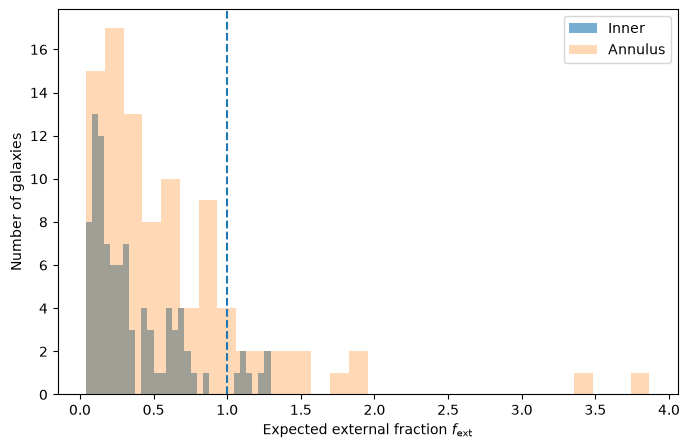

In [65]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    test_df["f_ext_inner"],
    bins=30,
    alpha=0.6,
    label="Inner",
)

ax.hist(
    test_df["f_ext_ann"],
    bins=30,
    alpha=0.3,
    label="Annulus",
)

ax.axvline(1.0, linestyle="--")

ax.set_xlabel(r"Expected external fraction $f_{\rm ext}$")
ax.set_ylabel("Number of galaxies")
ax.legend()

plt.show()


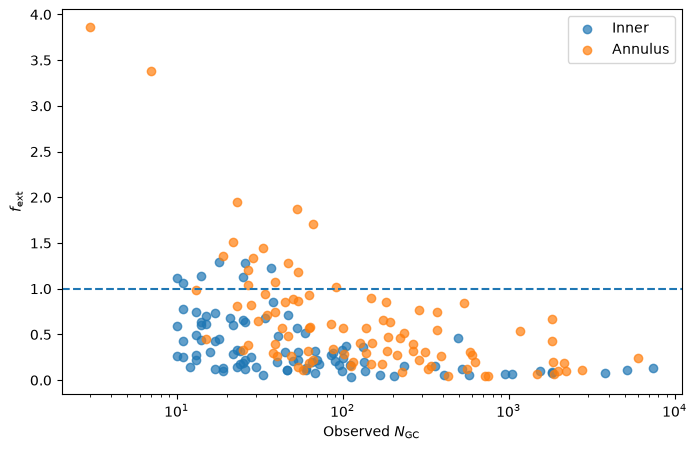

In [66]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    test_df["N_inner_Pblue"],
    test_df["f_ext_inner"],
    alpha=0.7,
    label="Inner",
)

ax.scatter(
    test_df["N_annulus_Pblue"],
    test_df["f_ext_ann"],
    alpha=0.7,
    label="Annulus",
)

ax.set_xscale("log")
ax.axhline(1.0, linestyle="--")

ax.set_xlabel(r"Observed $N_{\rm GC}$")
ax.set_ylabel(r"$f_{\rm ext}$")
ax.legend()

plt.show()

These plots actually make thing look much more manageable than I had expected.

The failures are concentrated almost entirely in the low-count systems, especially in the annulus. For most galaxies,

$$ f_{\rm ext}<1, $$

and for the richer systems it is usually comfortably below 0.5.

So at this stage a more accurate interpretation would be:

> The combined external correction is well behaved for most of the 93-galaxy science sample, but becomes unstable for a small subset of low-richness systems where the expected diffuse contribution approaches or exceeds the observed counts.

The scatter plot is especially useful because it shows the expected behavior very cleanly: as $ N_{\rm GC} $ increases, the external fraction drops rapidly. So this is not some mysterious environment-dependent failure; it’s basically a counting-statistics problem.

So, let's look at quantifying the survival fractions explicitly, e.g.:

In [67]:
for thresh in [0.5, 0.75, 1.0]:
    print(
        f"Inner f_ext >= {thresh}: "
        f"{(test_df['f_ext_inner'] >= thresh).sum()}"
    )
    print(
        f"Annulus f_ext >= {thresh}: "
        f"{(test_df['f_ext_ann'] >= thresh).sum()}"
    )
    print()



Inner f_ext >= 0.5: 24
Annulus f_ext >= 0.5: 43

Inner f_ext >= 0.75: 9
Annulus f_ext >= 0.75: 27

Inner f_ext >= 1.0: 7
Annulus f_ext >= 1.0: 15



In [68]:
for Nmin in [5, 10, 20]:
    print(
        f"N_corr >= {Nmin}: "
        f"inner={(test_df['N_inner_fg_icgc_sub'] >= Nmin).sum()}, "
        f"annulus={(test_df['N_ann_fg_icgc_sub'] >= Nmin).sum()}"
    )


N_corr >= 5: inner=81, annulus=73
N_corr >= 10: inner=65, annulus=68
N_corr >= 20: inner=52, annulus=62


In [69]:
valid_full = (
    (test_df["N_inner_fg_icgc_sub"] >= 10)
    & (test_df["N_ann_fg_icgc_sub"] >= 10)
)

print(valid_full.sum())


53


From this is would appear that $N_{\rm corr}\ge10$ is a very sensible fiducial/compromise cut.

If we inspect this overlap explicitly, and then list the mismatch cases, this will give us further details on what is behind this.

In [70]:
valid_inner = (
    test_df["N_inner_fg_icgc_sub"] >= 10
)

valid_ann = (
    test_df["N_ann_fg_icgc_sub"] >= 10
)

print("Inner only:", (valid_inner & ~valid_ann).sum())
print("Annulus only:", (~valid_inner & valid_ann).sum())
print("Both:", (valid_inner & valid_ann).sum())
print("Neither:", (~valid_inner & ~valid_ann).sum())


Inner only: 12
Annulus only: 15
Both: 53
Neither: 13


In [71]:
print(
    test_df.loc[
        valid_inner ^ valid_ann,
        [
            "N_inner_Pblue",
            "N_annulus_Pblue",
            "N_inner_fg_icgc_sub",
            "N_ann_fg_icgc_sub",
            "f_ext_inner",
            "f_ext_ann",
        ]
    ].to_string(float_format=lambda x: f"{x:.3f}")
)


     N_inner_Pblue  N_annulus_Pblue  N_inner_fg_icgc_sub  N_ann_fg_icgc_sub  f_ext_inner  f_ext_ann
8               10               27                7.385             16.538        0.262      0.387
15              22               85                8.838             32.353        0.598      0.619
35              26              149               -7.413             15.348        1.285      0.897
36              85               91               61.889             -1.371        0.272      1.015
56              12               15               10.318              8.273        0.140      0.448
59              28               27               21.006             -0.976        0.250      1.036
61              11               47                2.463             24.179        0.776      0.486
62              13               63                9.487             50.947        0.270      0.191
68              11               38                8.215             26.859        0.253      0.293


So, this table reveals that a simple “low-count systems fail” story is not the whole story.

Some mismatches are exactly what we'd expect from **sparse populations**, but others are **area-driven**. For example, one galaxy has N_annulus_Pblue = 53 yet the corrected annulus is -46.2, while another has N_annulus_Pblue = 605 and remains very healthy. Because the external correction is

$$ N_{\rm ext}=A_{\rm eff}\,\Sigma_{\rm ext}, $$

what matters is not simply $N_{\rm GC}$, but the observed surface density relative to the assumed external floor. An unusually large effective annulus with modest counts can therefore fail despite having dozens of candidates.

That means the 53-object intersection is a perfectly reasonable numerically stable subset, but before we use it scientifically we need to check that it has not selected a special environmental population - i.e., validate for selection effects. So, compare the 53 retained galaxies against the 40 excluded ones in $M_V$, local GC density, cluster-centric radius, tidal proxy, etc. If the retained sample is systematically richer/denser/brighter, then a change in correlation could partly be a sample-selection effect.
